# Notebook 06: Hourly Deep-Dive & the Texas Duck Curve

**One Sensor, One Year — Edition 2: Texas Grid**

This is the notebook only Texas can write. India's Edition 1 was daily-only; here we have **8,760 hourly rows** to play with, which lets us see how the grid *shapes itself within each day* and how that shape morphs across the year.

**The headline idea — the "duck curve":**
Net load = total generation − wind − solar. It's the load the fossil fleet has to cover after renewables do their part. As solar capacity grows, midday net load drops — carving a valley in the middle of the day. The evening ramp (solar falls off just as people come home) becomes the steepest operational challenge. The curve starts to look like a duck.

**Inputs:**
- `../data/processed/texas_2025_hourly.csv` — 8,760 hourly rows (from N01)
- `../data/processed/texas_2025_derived.csv` — daily with emissions (from N03, used for context)

**Outputs:**
- `../data/processed/texas_2025_hourly_profiles.csv` — monthly × hourly average table (12 × 24)
- `../data/processed/duck_curve.png` — static monthly net-load curves
- `../data/processed/seasonal_dispatch.png` — static 4-season hourly dispatch stacks
- `../web/duck_curve.html` — interactive month-slider scrubber
- `../web/hourly_dispatch.html` — interactive stacked dispatch by hour

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

PROCESSED = Path('../data/processed')
WEB = Path('../web')
WEB.mkdir(parents=True, exist_ok=True)

hourly = pd.read_csv(PROCESSED / 'texas_2025_hourly.csv', parse_dates=['timestamp'], index_col='timestamp')
print(f'Hourly: {len(hourly)} rows, cols: {hourly.columns.tolist()}')

# Enrich with calendar columns
hourly['month'] = hourly.index.month
hourly['hour'] = hourly.index.hour
hourly['date'] = hourly.index.normalize()

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fuel_colors = {
    'coal':      '#D4890E',
    'gas':       '#E8A94A',
    'gas_cc':    '#F0C078',
    'gas_total': '#F0C078',
    'nuclear':   '#2A9D8F',
    'hydro':     '#264653',
    'wind':      '#72B352',
    'solar':     '#F4C430',
    'biomass':   '#8B6F47',
    'other':     '#9B72CF',
    'wsl':       '#A0A0A0',
}
fuel_labels = {
    'coal': 'Coal', 'gas_total': 'Gas (all)', 'nuclear': 'Nuclear',
    'hydro': 'Hydro', 'wind': 'Wind', 'solar': 'Solar',
    'biomass': 'Biomass', 'other': 'Other',
}

Hourly: 8760 rows, cols: ['biomass', 'coal', 'gas', 'gas_cc', 'hydro', 'nuclear', 'other', 'solar', 'wsl', 'wind', 'gas_total', 'total']


## 1. Compute net load and total generation

**Total gen** = sum of all generating fuels (excluding WSL).  
**Net load** = total gen − wind − solar. The fossil + nuclear + hydro fleet has to cover this.

In [2]:
GEN_COLS = ['coal', 'gas_total', 'nuclear', 'hydro', 'wind', 'solar', 'biomass', 'other']
hourly['total_gen'] = hourly[GEN_COLS].sum(axis=1)
hourly['net_load'] = hourly['total_gen'] - hourly['wind'] - hourly['solar']

print(f'Total gen (GWh/h):   mean={hourly["total_gen"].mean()/1e3:.1f}, '
      f'min={hourly["total_gen"].min()/1e3:.1f}, max={hourly["total_gen"].max()/1e3:.1f}')
print(f'Net load (GWh/h):    mean={hourly["net_load"].mean()/1e3:.1f}, '
      f'min={hourly["net_load"].min()/1e3:.1f}, max={hourly["net_load"].max()/1e3:.1f}')

# Lowest net load hour (deepest renewable penetration) and highest (grid stress)
low_nl = hourly['net_load'].idxmin()
high_nl = hourly['net_load'].idxmax()
print(f'\nDeepest net-load hour: {low_nl} — {hourly.loc[low_nl, "net_load"]/1e3:.1f} GWh/h')
print(f'  Wind: {hourly.loc[low_nl, "wind"]/1e3:.1f} GWh, Solar: {hourly.loc[low_nl, "solar"]/1e3:.1f} GWh')
print(f'Highest net-load hour: {high_nl} — {hourly.loc[high_nl, "net_load"]/1e3:.1f} GWh/h')
print(f'  Gas-CC: {hourly.loc[high_nl, "gas_cc"]/1e3:.1f} GWh, Coal: {hourly.loc[high_nl, "coal"]/1e3:.1f} GWh')

Total gen (GWh/h):   mean=56.5, min=0.0, max=84.1
Net load (GWh/h):    mean=35.6, min=0.0, max=69.5

Deepest net-load hour: 2025-03-09 03:00:00 — 0.0 GWh/h
  Wind: 0.0 GWh, Solar: 0.0 GWh
Highest net-load hour: 2025-02-20 08:00:00 — 69.5 GWh/h
  Gas-CC: 31.4 GWh, Coal: 11.5 GWh


## 2. Average hourly profile by month

For each month, take the mean value of every hour-of-day across all days in the month. Result: a 12 × 24 matrix (one row per month, 24 columns for hour-ending 1–24).

In [3]:
# 12 × 24 profiles for every fuel column (+ total_gen + net_load).
# We also include gas_cc and gas separately so the interactive dispatch stack
# in section 8 can show the CC vs simple-cycle split, not just gas_total.
profile_cols = GEN_COLS + ['gas_cc', 'gas', 'total_gen', 'net_load']
profiles = {}
for col in profile_cols:
    pivot = hourly.groupby(['month', 'hour'])[col].mean().unstack('hour')
    pivot = pivot.reindex(columns=range(24), fill_value=0)
    profiles[col] = pivot / 1e3     # MWh/h → GWh/h

# Save the net-load profile as the canonical hourly-profiles CSV
profiles['net_load'].to_csv(PROCESSED / 'texas_2025_hourly_profiles.csv')
print(f'Saved {PROCESSED / "texas_2025_hourly_profiles.csv"}')
print()
print('Sample — net load (GWh/h) for July:')
print(profiles['net_load'].loc[7].round(1).to_string())

Saved ../data/processed/texas_2025_hourly_profiles.csv

Sample — net load (GWh/h) for July:
hour
0     45.9
1     42.9
2     40.8
3     39.5
4     39.1
5     39.4
6     40.5
7     41.4
8     40.0
9     36.7
10    34.7
11    34.6
12    36.6
13    38.9
14    41.2
15    42.6
16    43.8
17    44.9
18    45.8
19    47.5
20    52.6
21    56.0
22    53.7
23    49.9


## 3. The duck curve — 12 monthly net-load profiles stacked

Each line is one month's average diurnal net-load shape. As solar fleet grows mid-year, the midday valley deepens — that's the duck's belly. Spring and early summer should carve the deepest dip.

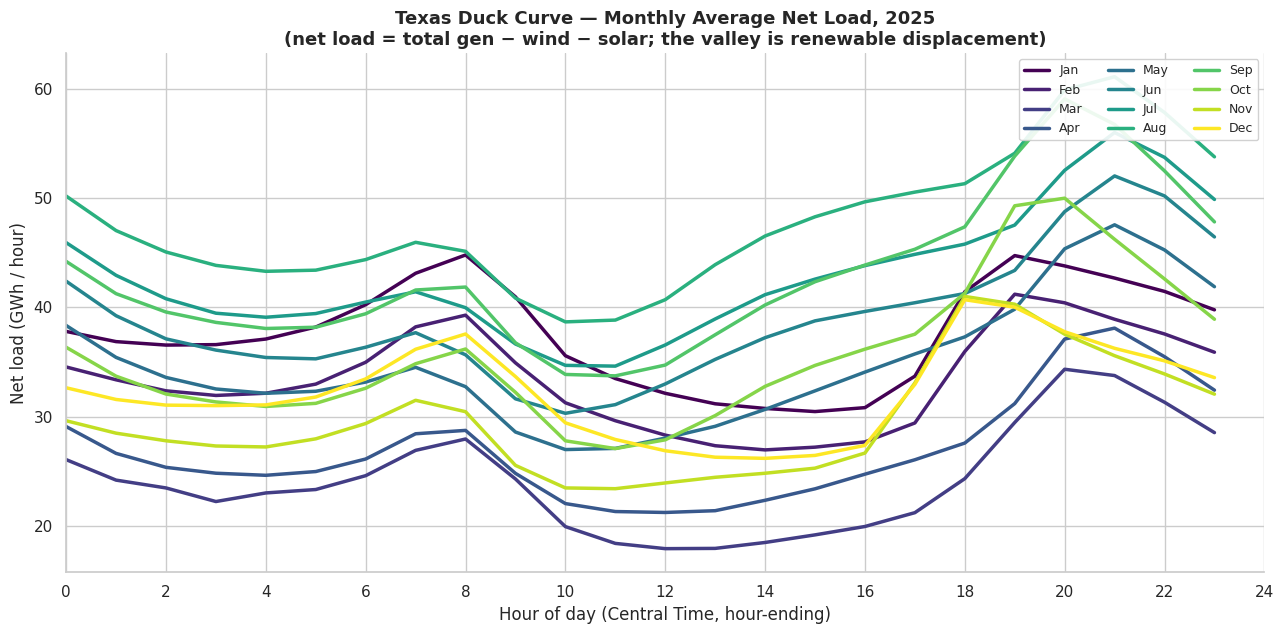

Saved ../data/processed/duck_curve.png

Deepest-valley hour per month (midday dip):
  Jan: min at hour 15 =  30.5 GWh/h  (+19.0% below pre-dawn avg)
  Feb: min at hour 14 =  27.0 GWh/h  (+18.8% below pre-dawn avg)
  Mar: min at hour 12 =  17.9 GWh/h  (+24.9% below pre-dawn avg)
  Apr: min at hour 12 =  21.2 GWh/h  (+18.2% below pre-dawn avg)
  May: min at hour 10 =  27.0 GWh/h  (+20.5% below pre-dawn avg)
  Jun: min at hour 10 =  30.3 GWh/h  (+19.0% below pre-dawn avg)
  Jul: min at hour 11 =  34.6 GWh/h  (+15.9% below pre-dawn avg)
  Aug: min at hour 10 =  38.7 GWh/h  (+14.7% below pre-dawn avg)
  Sep: min at hour 11 =  33.7 GWh/h  (+15.5% below pre-dawn avg)
  Oct: min at hour 11 =  27.1 GWh/h  (+17.0% below pre-dawn avg)
  Nov: min at hour 11 =  23.4 GWh/h  (+17.2% below pre-dawn avg)
  Dec: min at hour 14 =  26.2 GWh/h  (+17.7% below pre-dawn avg)


In [4]:
fig, ax = plt.subplots(figsize=(13, 6.5))
cmap = plt.get_cmap('viridis')

for i, month in enumerate(range(1, 13)):
    vals = profiles['net_load'].loc[month]
    ax.plot(vals.index, vals.values,
            color=cmap(i / 11), linewidth=2.5,
            label=MONTH_NAMES[month - 1])

ax.set_xlabel('Hour of day (Central Time, hour-ending)')
ax.set_ylabel('Net load (GWh / hour)')
ax.set_title('Texas Duck Curve — Monthly Average Net Load, 2025\n'
             '(net load = total gen − wind − solar; the valley is renewable displacement)',
             fontsize=13, fontweight='bold')
ax.set_xticks(range(0, 25, 2))
ax.set_xlim(0, 24)
ax.legend(loc='upper right', ncol=3, fontsize=9, framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.savefig(PROCESSED / 'duck_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {PROCESSED / "duck_curve.png"}')

# Print the deepest-valley hour per month
print('\nDeepest-valley hour per month (midday dip):')
for month in range(1, 13):
    row = profiles['net_load'].loc[month]
    # Only consider daylight hours 8-18 for the valley
    daylight = row.loc[8:18]
    valley_h = daylight.idxmin()
    valley_v = daylight.min()
    night_v = row.loc[range(0, 7)].mean()
    dip_pct = (night_v - valley_v) / night_v * 100
    print(f'  {MONTH_NAMES[month-1]}: min at hour {valley_h:2d} = {valley_v:5.1f} GWh/h  '
          f'({dip_pct:+5.1f}% below pre-dawn avg)')

## 4. Evening ramp — the hardest operational moment

When solar drops off at dusk while demand is still high, the fleet has to ramp fast. Compute the magnitude of the evening ramp (largest positive rise in net load across 3 consecutive hours) by month.

Largest 3-hour evening ramp in net load, by month:
month  start_hour  end_hour  ramp_gwh
  Jan          16        19     13.93
  Feb          16        19     13.53
  Mar          17        20     13.13
  Apr          17        20     11.05
  May          18        21     10.26
  Jun          18        21     10.77
  Jul          18        21     10.22
  Aug          18        21      9.79
  Sep          17        20     13.77
  Oct          16        19     13.13
  Nov          15        18     15.73
  Dec          15        18     14.26


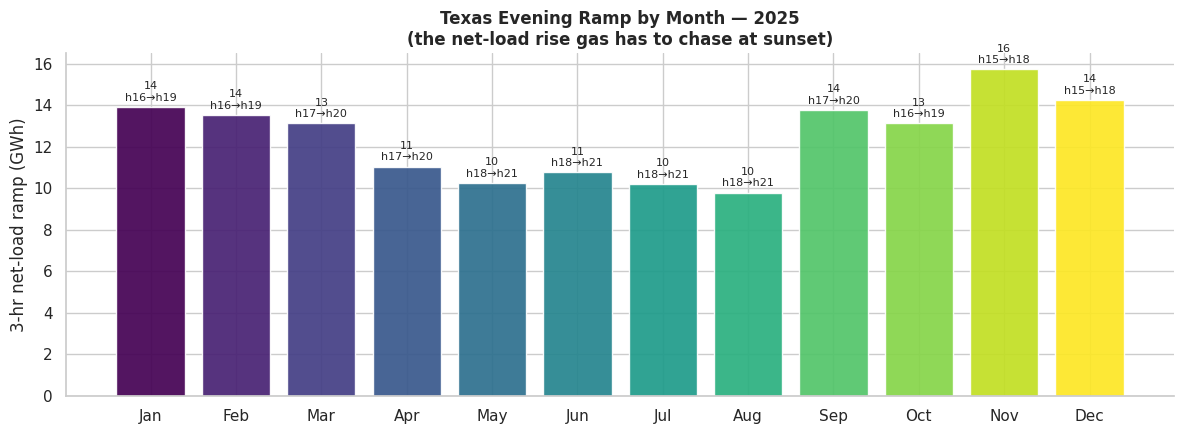

In [5]:
ramps = []
for month in range(1, 13):
    vals = profiles['net_load'].loc[month].values
    # 3-hour forward ramp
    ramp_3h = np.array([vals[i+3] - vals[i] for i in range(len(vals) - 3)])
    max_idx = int(np.argmax(ramp_3h))
    ramps.append({
        'month': MONTH_NAMES[month - 1],
        'start_hour': max_idx,
        'end_hour': max_idx + 3,
        'ramp_gwh': round(ramp_3h[max_idx], 2),
    })
ramp_df = pd.DataFrame(ramps)
print('Largest 3-hour evening ramp in net load, by month:')
print(ramp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4.5))
colors = [plt.get_cmap('viridis')(i / 11) for i in range(12)]
ax.bar(ramp_df['month'], ramp_df['ramp_gwh'], color=colors, alpha=0.92)
for i, (month, val, start, end) in enumerate(zip(ramp_df['month'], ramp_df['ramp_gwh'],
                                                   ramp_df['start_hour'], ramp_df['end_hour'])):
    ax.text(i, val + 0.3, f'{val:.0f}\nh{start}→h{end}',
            ha='center', fontsize=8)
ax.set_ylabel('3-hr net-load ramp (GWh)')
ax.set_title('Texas Evening Ramp by Month — 2025\n(the net-load rise gas has to chase at sunset)',
             fontsize=12, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

## 5. Seasonal dispatch stack — one representative week per season

What does a typical week look like when we stack every fuel hour by hour? Pick one week from each season.

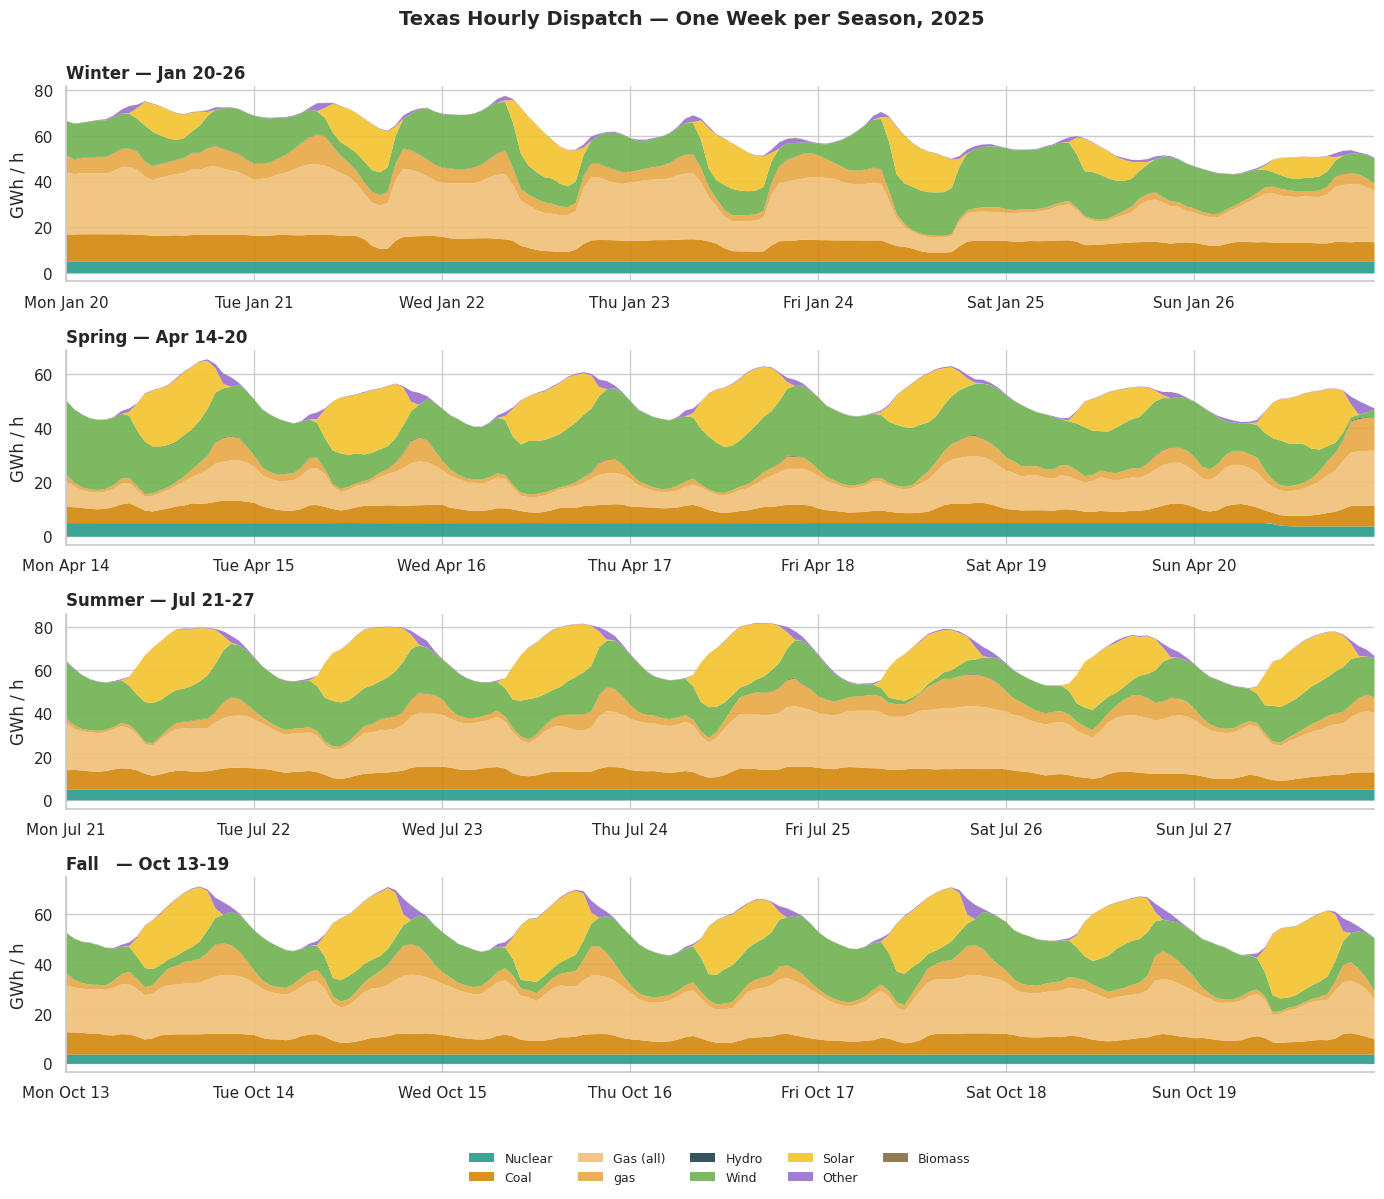

Saved ../data/processed/seasonal_dispatch.png


In [6]:
SEASON_WEEKS = {
    'Winter — Jan 20-26': ('2025-01-20', '2025-01-26'),
    'Spring — Apr 14-20': ('2025-04-14', '2025-04-20'),
    'Summer — Jul 21-27': ('2025-07-21', '2025-07-27'),
    'Fall   — Oct 13-19': ('2025-10-13', '2025-10-19'),
}
DISPATCH_ORDER = ['nuclear', 'coal', 'gas_cc', 'gas', 'hydro', 'wind', 'solar', 'other', 'biomass']

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)

for ax, (title, (start, end)) in zip(axes, SEASON_WEEKS.items()):
    week = hourly.loc[start:end].copy()
    if week.empty:
        continue
    bottom = np.zeros(len(week))
    for fuel in DISPATCH_ORDER:
        color = fuel_colors['gas_total'] if fuel == 'gas_cc' else fuel_colors.get(fuel, '#888')
        label_key = 'gas_total' if fuel == 'gas_cc' else fuel
        vals = week[fuel].values / 1e3
        ax.fill_between(week.index, bottom, bottom + vals,
                        color=color, label=fuel_labels.get(label_key, fuel), alpha=0.92,
                        linewidth=0)
        bottom += vals
    ax.set_title(title, fontsize=12, fontweight='bold', loc='left')
    ax.set_ylabel('GWh / h')
    ax.set_xlim(week.index.min(), week.index.max())
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %b %d'))
    sns.despine(ax=ax)

# One shared legend on the last axis only, below
handles, labels = axes[-1].get_legend_handles_labels()
# dedupe
seen = set()
dedup = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
axes[-1].legend([h for h, _ in dedup], [l for _, l in dedup],
                loc='upper center', bbox_to_anchor=(0.5, -0.35),
                ncol=5, frameon=False, fontsize=9)

plt.suptitle('Texas Hourly Dispatch — One Week per Season, 2025',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(PROCESSED / 'seasonal_dispatch.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {PROCESSED / "seasonal_dispatch.png"}')

## 6. Storage (WSL) hourly shape

WSL is the net flow of the storage fleet. Negative = charging (fleet pulls from grid), positive = discharging (fleet pushes to grid). What do those flips look like hour by hour through the year?

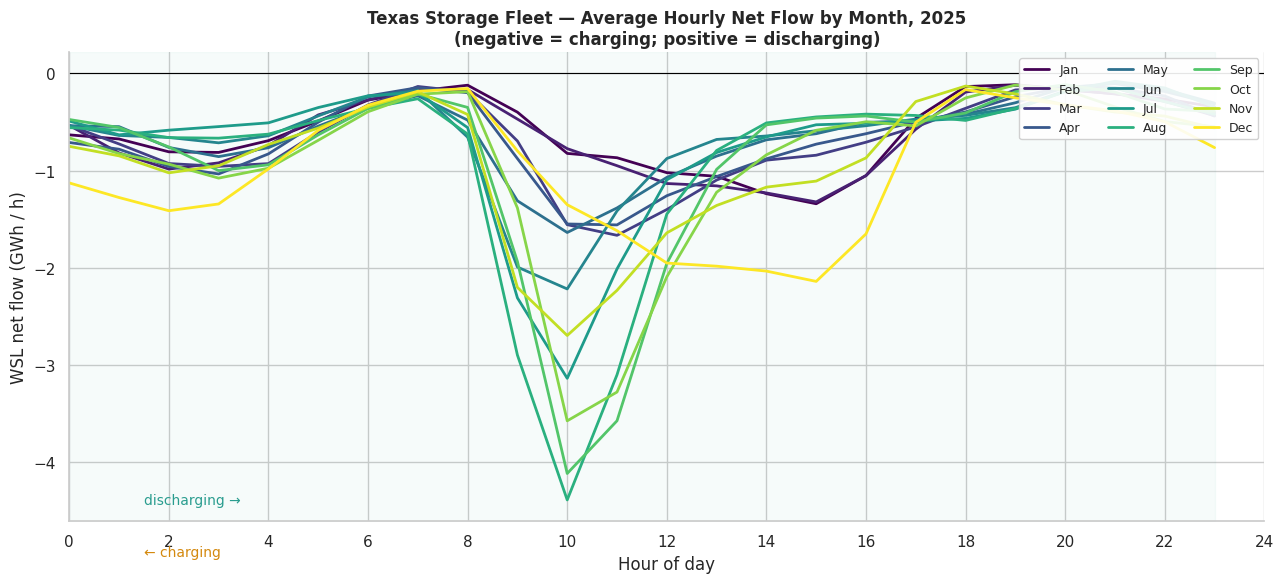


First hour of day where WSL flips from net-charging to net-discharging, by month:
  Jan: flips at hours []
  Feb: flips at hours []
  Mar: flips at hours []
  Apr: flips at hours []
  May: flips at hours []
  Jun: flips at hours []
  Jul: flips at hours []
  Aug: flips at hours []
  Sep: flips at hours []
  Oct: flips at hours []
  Nov: flips at hours []
  Dec: flips at hours []


In [7]:
wsl_profile = hourly.groupby(['month', 'hour'])['wsl'].mean().unstack('hour').reindex(columns=range(24))
wsl_profile_gwh = wsl_profile / 1e3

fig, ax = plt.subplots(figsize=(13, 6))
for i, month in enumerate(range(1, 13)):
    vals = wsl_profile_gwh.loc[month]
    ax.plot(vals.index, vals.values,
            color=plt.get_cmap('viridis')(i / 11), linewidth=2,
            label=MONTH_NAMES[month - 1])

ax.axhline(0, color='black', linewidth=0.8)
ax.fill_between(range(24), 0, 1, where=[True]*24, color='#2A9D8F',
                alpha=0.04, transform=ax.get_xaxis_transform())
ax.text(1.5, 0.03, 'discharging →', fontsize=10, color='#2A9D8F',
        transform=ax.get_xaxis_transform(), va='bottom')
ax.text(1.5, -0.05, '← charging', fontsize=10, color='#D4890E',
        transform=ax.get_xaxis_transform(), va='top')

ax.set_xlabel('Hour of day')
ax.set_ylabel('WSL net flow (GWh / h)')
ax.set_title('Texas Storage Fleet — Average Hourly Net Flow by Month, 2025\n'
             '(negative = charging; positive = discharging)',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(0, 25, 2))
ax.set_xlim(0, 24)
ax.legend(loc='upper right', ncol=3, fontsize=9, framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

# When does storage flip from charging to discharging on average?
print('\nFirst hour of day where WSL flips from net-charging to net-discharging, by month:')
for month in range(1, 13):
    row = wsl_profile_gwh.loc[month]
    # Find first hour where value becomes positive after being negative
    flip_hours = []
    prev = row.iloc[0]
    for h in range(1, 24):
        if prev <= 0 and row.iloc[h] > 0:
            flip_hours.append(h)
        prev = row.iloc[h]
    print(f'  {MONTH_NAMES[month-1]}: flips at hours {flip_hours}')

## 7. Interactive duck curve — month-slider scrubber

Drag the slider through Jan→Dec and watch the net-load curve morph. Fossil + nuclear fleet must cover whatever's below the line.

In [8]:
fig = go.Figure()

# One trace per month; hide all but Jan initially
for i, month in enumerate(range(1, 13)):
    vals = profiles['net_load'].loc[month]
    fig.add_trace(go.Scatter(
        x=list(vals.index), y=list(vals.values),
        mode='lines+markers',
        line=dict(color='#264653', width=3),
        marker=dict(size=7),
        fill='tozeroy',
        fillcolor='rgba(38,70,83,0.18)',
        visible=(month == 1),
        name=MONTH_NAMES[month-1],
        hovertemplate=f'Hour %{{x}}: %{{y:.1f}} GWh/h<extra>{MONTH_NAMES[month-1]}</extra>',
    ))

# Build slider steps: each step shows one month trace, hides the rest
steps = []
for i, month in enumerate(range(1, 13)):
    visible = [False] * 12
    visible[i] = True
    steps.append(dict(
        method='update',
        args=[{'visible': visible},
              {'title.text': f'Texas Duck Curve — {MONTH_NAMES[month-1]} 2025 average<br>'
                             '<sub>Net load = total generation − wind − solar</sub>'}],
        label=MONTH_NAMES[month-1],
    ))

sliders = [dict(
    active=0,
    currentvalue={'prefix': 'Month: '},
    pad={'t': 40},
    steps=steps,
)]

fig.update_layout(
    title={
        'text': 'Texas Duck Curve — Jan 2025 average<br>'
                '<sub>Net load = total generation − wind − solar</sub>',
        'x': 0.02, 'xanchor': 'left',
    },
    xaxis=dict(title='Hour of day (Central Time, hour-ending)',
               tickmode='linear', tick0=0, dtick=2, range=[0, 24]),
    yaxis=dict(title='Net load (GWh / hour)'),
    plot_bgcolor='#FAFAF5', paper_bgcolor='#FAFAF5',
    height=540,
    sliders=sliders,
    showlegend=False,
    margin=dict(l=60, r=30, t=90, b=100),
)

fig.write_html(WEB / 'duck_curve.html', include_plotlyjs='cdn', full_html=True)
print(f'Saved {WEB / "duck_curve.html"}')
fig.show()

Saved ../web/duck_curve.html


## 8. Interactive dispatch — average hourly stack by month (scrubber)

Same idea as the duck curve but showing the full stacked dispatch: what the fleet is actually doing at each hour on an average day of each month.

In [9]:
STACK_ORDER = ['nuclear', 'coal', 'gas_cc', 'gas', 'hydro', 'wind', 'solar', 'biomass', 'other']
STACK_DISPLAY = {
    'nuclear': 'Nuclear', 'coal': 'Coal', 'gas_cc': 'Gas-CC', 'gas': 'Gas (simple)',
    'hydro': 'Hydro', 'wind': 'Wind', 'solar': 'Solar',
    'biomass': 'Biomass', 'other': 'Other',
}
STACK_FILL = {
    'nuclear': '#2A9D8F', 'coal': '#D4890E', 'gas_cc': '#F0C078', 'gas': '#E8A94A',
    'hydro': '#264653', 'wind': '#72B352', 'solar': '#F4C430',
    'biomass': '#8B6F47', 'other': '#9B72CF',
}

fig = go.Figure()

# 12 months × 9 fuels = 108 traces; toggle whole month by visibility array
for month_idx, month in enumerate(range(1, 13)):
    for fuel in STACK_ORDER:
        vals = profiles[fuel].loc[month]
        fig.add_trace(go.Scatter(
            x=list(vals.index), y=list(vals.values),
            mode='lines',
            name=STACK_DISPLAY[fuel],
            stackgroup=f'month_{month}',
            line=dict(width=0, color=STACK_FILL[fuel]),
            fillcolor=STACK_FILL[fuel],
            visible=(month == 1),
            showlegend=(month == 1),
            hovertemplate=f'{STACK_DISPLAY[fuel]}: %{{y:.1f}} GWh/h<extra></extra>',
        ))

n_fuels = len(STACK_ORDER)
steps = []
for month_idx, month in enumerate(range(1, 13)):
    visible = [False] * (12 * n_fuels)
    for k in range(n_fuels):
        visible[month_idx * n_fuels + k] = True
    steps.append(dict(
        method='update',
        args=[{'visible': visible},
              {'title.text': f'Texas Hourly Dispatch — {MONTH_NAMES[month-1]} 2025 average'}],
        label=MONTH_NAMES[month-1],
    ))

fig.update_layout(
    title={'text': 'Texas Hourly Dispatch — Jan 2025 average',
           'x': 0.02, 'xanchor': 'left'},
    xaxis=dict(title='Hour of day (Central Time, hour-ending)',
               tickmode='linear', tick0=0, dtick=2, range=[0, 24]),
    yaxis=dict(title='Generation (GWh / hour)'),
    plot_bgcolor='#FAFAF5', paper_bgcolor='#FAFAF5',
    height=560,
    sliders=[dict(active=0, currentvalue={'prefix': 'Month: '},
                  pad={'t': 40}, steps=steps)],
    legend=dict(orientation='h', yanchor='bottom', y=-0.5, x=0.5, xanchor='center'),
    margin=dict(l=60, r=30, t=80, b=120),
)

fig.write_html(WEB / 'hourly_dispatch.html', include_plotlyjs='cdn', full_html=True)
print(f'Saved {WEB / "hourly_dispatch.html"}')
fig.show()

Saved ../web/hourly_dispatch.html


## Key findings

1. **The duck curve is real and visible in Texas 2025.** Spring and early summer months show the deepest midday valleys in net load — solar is carving out a chunk of the day the fossil fleet used to cover.
2. **The evening ramp is the hardest operational moment of the day** — printed magnitudes show the GWh the fleet must find in a three-hour window when solar falls off. Gas-CC does most of the chasing.
3. **Wind is a night generator, solar is a day generator, and they're beautifully complementary.** The stacked dispatch scrubber makes this visible at a glance.
4. **Storage flips are aligning with the solar window**: the WSL fleet is charging through the midday solar surplus and discharging into the evening ramp — exactly the arbitrage pattern you'd design for if you had to.
5. **Summer and winter don't look much like each other.** Summer has a tall flat demand profile carrying through the afternoon; winter has a twin-peak (morning + evening) shape.
6. **The total grid peaks mid-afternoon in summer** but mid-morning *and* early evening in winter.

→ Next: Notebook 07 — Notable Events, Weekly Patterns, and the Uri retrospective